# Heart Disease Risk Predictor
# Hyperparameter Tuning

## Objective
This notebook optimizes the best-performing baseline machine learning models identified in the previous modeling stage.

The objectives are:
- Identify the top baseline models based on ROC-AUC
- Define suitable hyperparameter search spaces
- Perform cross-validation
- Optimize model hyperparameters using RandomizedSearchCV
- Compare baseline and tuned model performance
- Select the final model for explainability analysis
- Save the optimized model and tuning results

In [41]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER = 20
PROJECT_ROOT = Path("..")
PROCESSED_DIR = PROJECT_ROOT/"data"/"processed"
MODEL_DIR = PROJECT_ROOT/"models"
RESULT_DIR = PROJECT_ROOT/"results"
TUNING_RESULT_DIR = RESULT_DIR/"tuning"
TUNING_IMAGE_DIR = PROJECT_ROOT/"images"/"modeling"
TUNING_RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
TUNING_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)
DPI = 300

In [3]:
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(
        TUNING_IMAGE_DIR / f"{filename}.png",
        dpi=DPI,
        bbox_inches="tight"
    )
    print(f"✓ Saved : {filename}.png")

# Load Processed Dataset
The processed datasets generated in Notebook 04 are loaded for hyperparameter tuning.
Both scaled and non-scaled datasets are available because the preprocessing requirements depend on the selected machine learning algorithms.

In [4]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")
X_train_scaled = pd.read_csv(PROCESSED_DIR / "X_train_scaled.csv")
X_test_scaled = pd.read_csv(PROCESSED_DIR / "X_test_scaled.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

# Load Baseline Model Results
The baseline evaluation results generated in Notebook 05 are loaded to identify the two best-performing models for hyperparameter tuning.

In [5]:
baseline_results = pd.read_csv(RESULT_DIR / "model_comparison.csv")
baseline_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723
3,K-Nearest Neighbors,0.885246,0.800000,1.000000,0.888889,0.923160
4,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
5,Decision Tree,0.737705,0.676471,0.821429,0.741935,0.744048


In [6]:
baseline_results = (baseline_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True))
baseline_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.885246,0.838710,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.951299
2,Support Vector Machine,0.852459,0.806452,0.892857,0.847458,0.943723
3,K-Nearest Neighbors,0.885246,0.800000,1.000000,0.888889,0.923160
4,XGBoost,0.852459,0.787879,0.928571,0.852459,0.918831
5,Decision Tree,0.737705,0.676471,0.821429,0.741935,0.744048


In [7]:
top_models = (baseline_results.head(2).copy())
top_models

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.885246,0.83871,0.928571,0.881356,0.951840
1,Logistic Regression,0.868852,0.81250,0.928571,0.866667,0.951299


In [8]:
print("Top 2 baseline models:")

for i, model_name in enumerate(top_models["Model"], start=1):
    print(f"{i}. {model_name}")

Top 2 baseline models:
1. Random Forest
2. Logistic Regression


### Model Selection Strategy
The two highest-performing baseline models based on ROC-AUC are selected for hyperparameter tuning.
This approach reduces unnecessary computational cost while focusing optimization efforts on the models that demonstrated the strongest baseline performance.

In [9]:
cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [10]:
print(
    f"Cross-validation strategy: "
    f"{CV_FOLDS}-Fold Stratified Cross-Validation"
)

Cross-validation strategy: 5-Fold Stratified Cross-Validation


In [11]:
rf_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

In [12]:
xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.5]
}

# Hyperparameter Search Spaces
Different hyperparameter search spaces are defined for each candidate model.
RandomizedSearchCV will randomly sample combinations from these search spaces and evaluate them using stratified cross-validation.
ROC-AUC is used as the primary optimization metric because the project focuses on distinguishing patients with and without heart disease across different classification thresholds.

# Hyperparameter Tuning
Hyperparameter tuning is performed on the two best-performing baseline models.
RandomizedSearchCV is used to efficiently explore different hyperparameter combinations, while Stratified K-Fold Cross-Validation maintains the target class distribution across validation folds.
ROC-AUC is used as the optimization metric.

In [13]:
from scipy.stats import loguniform
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [14]:
logistic_param_distributions = {
    "C": loguniform(1e-3, 1e2),
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"],
    "max_iter": [1000]
}

knn_param_distributions = {
    "n_neighbors": list(range(3, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

svm_param_distributions = {
    "C": loguniform(1e-2, 1e2),
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"]
}

dt_param_distributions = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"]
}

# Candidate Model Configuration
Each candidate model is associated with its corresponding hyperparameter search space and preprocessing requirements.
Scale-sensitive models use standardized features, while tree-based models use the original feature values.

In [15]:
tuning_config = {
    "Logistic Regression": {
        "model": LogisticRegression(
            random_state=RANDOM_STATE
        ),
        "params": logistic_param_distributions,
        "scaled": True
    },

    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": knn_param_distributions,
        "scaled": True
    },

    "Support Vector Machine": {
        "model": SVC(
            probability=True,
            random_state=RANDOM_STATE
        ),
        "params": svm_param_distributions,
        "scaled": True
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),
        "params": dt_param_distributions,
        "scaled": False
    },

    "Random Forest": {
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE
        ),
        "params": rf_param_distributions,
        "scaled": False
    },

    "XGBoost": {
        "model": XGBClassifier(
            random_state=RANDOM_STATE,
            eval_metric="logloss"
        ),
        "params": xgb_param_distributions,
        "scaled": False
    }
}

In [16]:
selected_model_names = top_models["Model"].tolist()
selected_model_names

['Random Forest', 'Logistic Regression']

In [17]:
tuned_models = {}
tuning_results = []
search_objects = {}

# Run Randomized Hyperparameter Search
RandomizedSearchCV evaluates randomly selected hyperparameter combinations using stratified cross-validation.
Only the two strongest baseline models are optimized to keep the tuning process computationally efficient.

In [18]:
for model_name in selected_model_names:
    print(f"Tuning: {model_name}")

    config = tuning_config[model_name]

    model = config["model"]
    params = config["params"]

    if config["scaled"]:
        X_train_tuning = X_train_scaled
    else:
        X_train_tuning = X_train

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search.fit(X_train_tuning, y_train)
    tuned_models[model_name] = search.best_estimator_
    search_objects[model_name] = search

    print()
    print(f"Best ROC-AUC CV : {search.best_score_:.4f}")
    print("Best Parameters:")
    print(search.best_params_)
    print()

Tuning: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best ROC-AUC CV : 0.8886
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': 'balanced'}

Tuning: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best ROC-AUC CV : 0.9007
Best Parameters:
{'C': np.float64(0.028888383623653185), 'class_weight': 'balanced', 'max_iter': 1000, 'solver': 'liblinear'}



# Best Hyperparameters
The best hyperparameter combination identified for each candidate model is displayed below.

In [19]:
for model_name, search in search_objects.items():
    print(model_name)
    print(f"Best CV ROC-AUC : {search.best_score_:.4f}")
    print("\nBest Parameters:")

    for parameter, value in search.best_params_.items():
        print(f"{parameter}: {value}")
    print()

Random Forest
Best CV ROC-AUC : 0.8886

Best Parameters:
n_estimators: 200
min_samples_split: 5
min_samples_leaf: 4
max_features: sqrt
max_depth: 15
class_weight: balanced

Logistic Regression
Best CV ROC-AUC : 0.9007

Best Parameters:
C: 0.028888383623653185
class_weight: balanced
max_iter: 1000
solver: liblinear



# Save Hyperparameter Search Results
The complete cross-validation results are exported for reproducibility and further analysis.
This provides a record of the parameter combinations evaluated during hyperparameter tuning.

In [20]:
for model_name, search in search_objects.items():
    safe_name = (model_name.lower().replace(" ", "_").replace("-", ""))
    cv_results = pd.DataFrame(search.cv_results_)
    cv_results.to_csv(TUNING_RESULT_DIR/f"{safe_name}_tuning_results.csv", index=False)

In [21]:
import json

In [22]:
best_parameters = {}

for model_name, search in search_objects.items():
    best_parameters[model_name] = {
        key: (
            value.item()
            if isinstance(value, np.generic)
            else value
        )
        for key, value in search.best_params_.items()
    }

with open(TUNING_RESULT_DIR/"best_parameters.json", "w", encoding="utf-8"
) as file:
    json.dump(best_parameters, file, indent=4)

# Save Tuned Models
The optimized models are saved separately so they can be reused without repeating the hyperparameter search process.

In [23]:
for model_name, model in tuned_models.items():
    safe_name = (model_name.lower().replace(" ", "_").replace("-", ""))
    joblib.dump(model, MODEL_DIR/f"{safe_name}_tuned.pkl")

In [24]:
print("Tuning Results:")
for file in sorted(TUNING_RESULT_DIR.iterdir()):
    print("-", file.name)

print("\nTuned Models:")
for file in sorted(MODEL_DIR.glob("*_tuned.pkl")):
    print("-", file.name)

Tuning Results:
- best_parameters.json
- logistic_regression_tuning_results.csv
- random_forest_tuning_results.csv

Tuned Models:
- logistic_regression_tuned.pkl
- random_forest_tuned.pkl


# Evaluate Tuned Models
The optimized models are evaluated on the held-out test set to measure their generalization performance.
The test set was not used during hyperparameter tuning, allowing an unbiased comparison between baseline and tuned models.

In [25]:
def evaluate_tuned_model(model, X_test_data, y_test_data):
    prediction = model.predict(X_test_data)
    probability = model.predict_proba(X_test_data)[:, 1]
    metrics = {"Accuracy": accuracy_score( y_test_data, prediction),
        "Precision": precision_score(y_test_data, prediction),
        "Recall": recall_score(y_test_data, prediction),
        "F1-Score": f1_score(y_test_data, prediction),
        "ROC-AUC": roc_auc_score(y_test_data, probability)
    }
    return prediction, probability, metrics

In [26]:
tuned_predictions = {}
tuned_probabilities = {}
tuned_results = []

In [27]:
for model_name, model in tuned_models.items():
    config = tuning_config[model_name]

    if config["scaled"]:
        X_test_tuning = X_test_scaled
    else:
        X_test_tuning = X_test

    prediction, probability, metrics = evaluate_tuned_model(model, X_test_tuning, y_test)
    tuned_predictions[model_name] = prediction
    tuned_probabilities[model_name] = probability
    tuned_results.append({"Model": model_name, **metrics})

In [28]:
tuned_results_df = (pd.DataFrame(tuned_results).sort_values(by="ROC-AUC",ascending=False).reset_index(drop=True))
tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.8852,0.8387,0.9286,0.8814,0.9610
1,Logistic Regression,0.8525,0.8065,0.8929,0.8475,0.9567


# Baseline vs Tuned Model Comparison
The performance of each tuned model is compared with its corresponding baseline model.
This comparison determines whether hyperparameter tuning provides a meaningful improvement in predictive performance.

In [29]:
comparison_rows = []

for model_name in tuned_results_df["Model"]:
    baseline_row = baseline_results[baseline_results["Model"] == model_name].iloc[0]
    tuned_row = tuned_results_df[tuned_results_df["Model"] == model_name].iloc[0]
    comparison_rows.append({
        "Model": model_name,
        "Baseline Accuracy": baseline_row["Accuracy"],
        "Tuned Accuracy": tuned_row["Accuracy"],
        "Baseline Precision": baseline_row["Precision"],
        "Tuned Precision": tuned_row["Precision"],
        "Baseline Recall": baseline_row["Recall"],
        "Tuned Recall": tuned_row["Recall"],
        "Baseline F1-Score": baseline_row["F1-Score"],
        "Tuned F1-Score": tuned_row["F1-Score"],
        "Baseline ROC-AUC": baseline_row["ROC-AUC"],
        "Tuned ROC-AUC": tuned_row["ROC-AUC"]
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.round(4)

,Model,Baseline Accuracy,Tuned Accuracy,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1-Score,Tuned F1-Score,Baseline ROC-AUC,Tuned ROC-AUC
0,Random Forest,0.8852,0.8852,0.8387,0.8387,0.9286,0.9286,0.8814,0.8814,0.9518,0.9610
1,Logistic Regression,0.8689,0.8525,0.8125,0.8065,0.9286,0.8929,0.8667,0.8475,0.9513,0.9567


In [30]:
comparison_df["ROC-AUC Improvement"] = (comparison_df["Tuned ROC-AUC"] - comparison_df["Baseline ROC-AUC"])
comparison_df["F1 Improvement"] = (comparison_df["Tuned F1-Score"] - comparison_df["Baseline F1-Score"])
comparison_df.round(4)

,Model,Baseline Accuracy,Tuned Accuracy,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1-Score,Tuned F1-Score,Baseline ROC-AUC,Tuned ROC-AUC,ROC-AUC Improvement,F1 Improvement
0,Random Forest,0.8852,0.8852,0.8387,0.8387,0.9286,0.9286,0.8814,0.8814,0.9518,0.9610,0.0092,0.0000
1,Logistic Regression,0.8689,0.8525,0.8125,0.8065,0.9286,0.8929,0.8667,0.8475,0.9513,0.9567,0.0054,-0.0192


In [31]:
comparison_df.to_csv(TUNING_RESULT_DIR/"baseline_vs_tuned.csv", index=False)
comparison_df.to_excel(TUNING_RESULT_DIR/"baseline_vs_tuned.xlsx", index=False)

# ROC-AUC Improvement
The following visualization shows whether hyperparameter tuning improved the ROC-AUC score of each selected model.

In [32]:
plot_df = comparison_df[["Model", "Baseline ROC-AUC", "Tuned ROC-AUC"]].melt(
    id_vars="Model",
    var_name="Version",
    value_name="ROC-AUC"
)

✓ Saved : baseline_vs_tuned_roc_auc.png


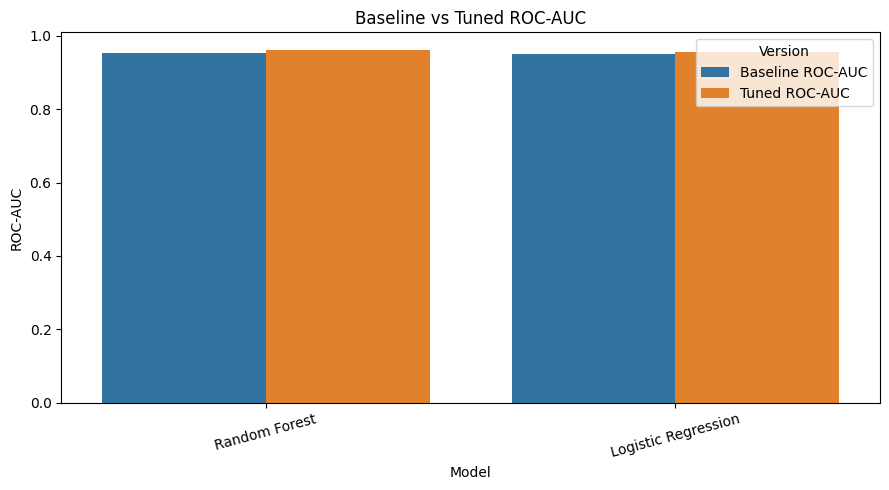

In [33]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=plot_df,
    x="Model",
    y="ROC-AUC",
    hue="Version"
)

plt.title("Baseline vs Tuned ROC-AUC")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
save_plot("baseline_vs_tuned_roc_auc")
plt.show()

# Final Model Selection
The final model is selected based primarily on ROC-AUC, while Precision, Recall, and F1-Score are also considered.
For a healthcare risk prediction problem, Recall is particularly important because false negatives represent patients with heart disease who are incorrectly classified as low risk.
Therefore, the final model should not be selected solely from accuracy.

In [34]:
final_model_row = (tuned_results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0])
final_model_name = final_model_row["Model"]
final_model = tuned_models[final_model_name]

In [35]:
print(f"Final Model: {final_model_name}")
print(f"Accuracy : {final_model_row['Accuracy']:.4f}")
print(f"Precision: {final_model_row['Precision']:.4f}")
print(f"Recall   : {final_model_row['Recall']:.4f}")
print(f"F1-Score : {final_model_row['F1-Score']:.4f}")
print(f"ROC-AUC  : {final_model_row['ROC-AUC']:.4f}")

Final Model: Random Forest
Accuracy : 0.8852
Precision: 0.8387
Recall   : 0.9286
F1-Score : 0.8814
ROC-AUC  : 0.9610


# Save Final Model
The selected tuned model is saved as the final model for the explainability stage.
This model will be loaded in the SHAP analysis notebook.

In [36]:
joblib.dump(final_model, MODEL_DIR/"final_model.pkl")
print(f"Final model saved: {MODEL_DIR/'final_model.pkl'}")

Final model saved: ..\models\final_model.pkl


In [37]:
final_model_config = {
    "model_name": final_model_name,
    "uses_scaled_features": tuning_config[final_model_name]["scaled"],
    "selection_metric": "ROC-AUC"
}

In [38]:
with open(TUNING_RESULT_DIR / "final_model_config.json", "w", encoding="utf-8") as file:
    json.dump(final_model_config, file, indent=4)

In [39]:
final_prediction = tuned_predictions[final_model_name]

In [42]:
final_report = classification_report(y_test, final_prediction)
print(final_report)

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [43]:
with open(TUNING_RESULT_DIR / "final_model_classification_report.txt", "w", encoding="utf-8"
) as file:
    file.write(f"Final Model: {final_model_name}\n\n")
    file.write(final_report)

# Final Model Confusion Matrix
The confusion matrix is used to examine the types of classification errors produced by the final tuned model.

In [44]:
final_cm = confusion_matrix(y_test, final_prediction)

✓ Saved : final_model_confusion_matrix.png


<Figure size 600x600 with 0 Axes>

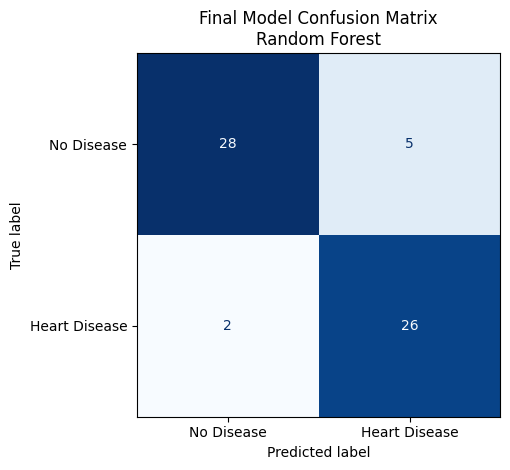

In [45]:
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["No Disease", "Heart Disease"]
).plot(cmap="Blues", colorbar=False)
plt.title(f"Final Model Confusion Matrix\n{final_model_name}")
save_plot("final_model_confusion_matrix")
plt.show()

# Final Model Summary
The final model performance and tuning information are documented in a summary file for future reference.

In [46]:
final_summary = f"""
Heart Disease Risk Predictor
Final Model Summary

Final Model
{final_model_name}

Selection Metric
ROC-AUC

Test Performance

Accuracy  : {final_model_row["Accuracy"]:.4f}
Precision : {final_model_row["Precision"]:.4f}
Recall    : {final_model_row["Recall"]:.4f}
F1-Score  : {final_model_row["F1-Score"]:.4f}
ROC-AUC   : {final_model_row["ROC-AUC"]:.4f}

"""

In [47]:
with open(TUNING_RESULT_DIR/"final_model_summary.txt", "w", encoding="utf-8") as file:
    file.write(final_summary)

print(final_summary)


Heart Disease Risk Predictor
Final Model Summary

Final Model
Random Forest

Selection Metric
ROC-AUC

Test Performance

Accuracy  : 0.8852
Precision : 0.8387
Recall    : 0.9286
F1-Score  : 0.8814
ROC-AUC   : 0.9610




In [48]:
print("TUNING RESULTS")
for file in sorted(TUNING_RESULT_DIR.iterdir()):print(file.name)

print("\nFINAL MODEL")
for file in sorted(MODEL_DIR.glob("*final_model*")):print(file.name)

print("\nMODELING IMAGES")
for file in sorted(TUNING_IMAGE_DIR.iterdir()):
    print(file.name)

TUNING RESULTS
baseline_vs_tuned.csv
baseline_vs_tuned.xlsx
best_parameters.json
final_model_classification_report.txt
final_model_config.json
final_model_summary.txt
logistic_regression_tuning_results.csv
random_forest_tuning_results.csv

FINAL MODEL
final_model.pkl

MODELING IMAGES
accuracy_comparison.png
baseline_vs_tuned_roc_auc.png
confusion_matrix_best_model.png
f1_comparison.png
feature_importance.png
final_model_confusion_matrix.png
precision_comparison.png
recall_comparison.png
roc_auc_comparison.png
roc_curve_all_models.png


# Conclusion
Hyperparameter tuning was performed on the two strongest baseline models using RandomizedSearchCV with stratified cross-validation.
The optimized models were evaluated on the held-out test set and compared against their baseline versions.
The final model was selected based primarily on ROC-AUC while also considering Precision, Recall, and F1-Score.
The final tuned model has been saved and is ready for the next stage: model explainability using SHAP.
The SHAP analysis will investigate which clinical features contribute most strongly to the model's predictions and how individual patient characteristics influence predicted heart disease risk.